[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sensioai/blog/blob/master/032_optimization/optimization.ipynb)

# Optimización

En este post vamos a ver algunas técnicas que podemos aplicar durante el entrenamiento de nuestras `redes neuronales` para acelerar el proceso de optimización y, potencialmente, obtener mejores resultados de los que hemos sido capaces de obtener hasta ahora. Compararemos estas técnicas en el mismo problema utilizado en el post anterior, la clasificación de imágenes con el dataset dog-breed-indentification

In [ ]:
import os, numpy as np, pandas as pd
from PIL import Image
import torch, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# AJUSTA ESTA RUTA A TU PC (usa r"..." en Windows para evitar backslashes)
BASE_DIR   = r"C:\Users\Mi Chelsy\Desktop\IA\IA\LAB6\dog-breed-identification"   # <-- CAMBIA AQUÍ
TRAIN_DIR  = f"{BASE_DIR}/train"
TEST_DIR   = f"{BASE_DIR}/test"
LABELS_CSV = f"{BASE_DIR}/labels.csv"

IMG_SIZE = 32  # igual que CIFAR-10 para no tocar el resto

def read_img(p, size=IMG_SIZE):
    return Image.open(p).convert("RGB").resize((size, size))

# 1) Labels y clases
labels_df   = pd.read_csv(LABELS_CSV)    # columnas: id, breed
class_names = sorted(labels_df["breed"].unique().tolist())
cls2idx     = {c:i for i,c in enumerate(class_names)}

# 2) trainset: lista de (PIL.Image, label)
train_paths  = [os.path.join(TRAIN_DIR, f"{i}.jpg") for i in labels_df["id"]]
train_labels = [cls2idx[b] for b in labels_df["breed"]]
trainset     = [(read_img(p), y) for p, y in zip(train_paths, train_labels) if os.path.exists(p)]

# 3) testset: lista de (PIL.Image, -1)
test_files = sorted([f for f in os.listdir(TEST_DIR) if f.lower().endswith(".jpg")])
test_paths = [os.path.join(TEST_DIR, f) for f in test_files]
testset    = [(read_img(p), -1) for p in test_paths]

# 4) variables equivalentes a CIFAR-10
classes     = tuple(class_names)
num_classes = len(classes)

print("Clases:", num_classes)
print("len(trainset), len(testset) =", len(trainset), len(testset))


Clases: 120
len(trainset), len(testset) = 10222 10357


In [122]:
train_images = np.array([np.array(img) for img, _ in trainset], dtype=np.uint8)
train_labels = np.array([y for _, y in trainset], dtype=np.int64)

X_test = np.array([np.array(img) for img, _ in testset], dtype=np.uint8)
y_test = np.array([y for _, y in testset], dtype=np.int64)   # -1s, OK

X_train, X_val, y_train, y_val = train_test_split(
    train_images, train_labels, test_size=0.2, random_state=42, stratify=train_labels
)

SUBSET_SIZE = min(5000, len(X_train))  # como el cuadernillo (5k); baja si te falta RAM
X_subset, _, y_subset, _ = train_test_split(
    X_train, y_train, train_size=SUBSET_SIZE, random_state=42, stratify=y_train
)

X_train.shape, X_val.shape, X_test.shape, X_subset.shape


((8177, 32, 32, 3), (2045, 32, 32, 3), (10357, 32, 32, 3), (5000, 32, 32, 3))

In [123]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        x = torch.from_numpy(X / 255.).float()         # [N,32,32,3] -> [0,1]
        y = torch.from_numpy(Y).long()
        self.X = x.view(-1, 32*32*3).to(device)        # aplanado como el MLP del cuadernillo
        self.Y = y.to(device)
    def __len__(self): return len(self.X)
    def __getitem__(self, ix): return self.X[ix], self.Y[ix]

dataset = {
    'train': Dataset(X_subset, y_subset),   # igual que el cuadernillo
    'val':   Dataset(X_val,    y_val),
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32,   shuffle=True),
    'val':   torch.utils.data.DataLoader(dataset['val'],   batch_size=1000, shuffle=False),
}
len(dataset['train']), len(dataset['val'])

(5000, 2045)

In [127]:
def batch_acc_from_logits(logits, y_true):
    preds = logits.argmax(dim=1)
    return (preds == y_true).float().mean().item()

In [138]:
from sklearn.metrics import accuracy_score

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

def build_model(D_in=32*32*3, H=100, D_out=None):
    if D_out is None:
        D_out = len(classes)
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    )
model = build_model(D_out=len(classes))
print("out_features (debe ser 120):", list(model.modules())[-1].out_features)
def fit(model, dataloader, optimizer, epochs=100, log_each=10, weight_decay=0, early_stopping=0):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            _acc.append(batch_acc_from_logits(y_pred, y_b))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                _acc.append(batch_acc_from_logits(y_pred, y_b))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}

out_features (debe ser 120): 120


## Optimizadores

### Momentum

### RMSProp

### Adam

### Comparativa

Vamos a comparar los diferentes optimizadores presentados.

In [88]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
hist_sgd = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.01441 en epoch 1
Mejor modelo guardado con acc 0.01641 en epoch 2
Mejor modelo guardado con acc 0.01741 en epoch 3
Mejor modelo guardado con acc 0.02315 en epoch 6
Mejor modelo guardado con acc 0.02315 en epoch 7
Mejor modelo guardado con acc 0.02415 en epoch 8
Epoch 10/100 loss 4.78344 acc 0.01234 val_loss 4.78557 val_acc 0.02348
Epoch 20/100 loss 4.77778 acc 0.01393 val_loss 4.78213 val_acc 0.02415
Epoch 30/100 loss 4.77192 acc 0.01373 val_loss 4.77852 val_acc 0.01707
Epoch 40/100 loss 4.76500 acc 0.01373 val_loss 4.77435 val_acc 0.01841
Epoch 50/100 loss 4.75678 acc 0.01553 val_loss 4.76867 val_acc 0.01574
Epoch 60/100 loss 4.74626 acc 0.01990 val_loss 4.76062 val_acc 0.01000
Epoch 70/100 loss 4.73204 acc 0.02189 val_loss 4.74907 val_acc 0.01774
Epoch 80/100 loss 4.71319 acc 0.02090 val_loss 4.73207 val_acc 0.01200
Epoch 90/100 loss 4.68929 acc 0.02110 val_loss 4.70921 val_acc 0.01567
Epoch 100/100 loss 4.65796 acc 0.02548 val_loss 4.68126 val_acc 0.0

In [89]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_momentum = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.01441 en epoch 1
Mejor modelo guardado con acc 0.02074 en epoch 8
Epoch 10/100 loss 4.69219 acc 0.02289 val_loss 4.69039 val_acc 0.01233
Mejor modelo guardado con acc 0.02607 en epoch 17
Mejor modelo guardado con acc 0.02707 en epoch 20
Epoch 20/100 loss 4.53048 acc 0.02846 val_loss 4.56807 val_acc 0.02707
Mejor modelo guardado con acc 0.02841 en epoch 24
Mejor modelo guardado con acc 0.02874 en epoch 26
Mejor modelo guardado con acc 0.02907 en epoch 27
Mejor modelo guardado con acc 0.03107 en epoch 30
Epoch 30/100 loss 4.43415 acc 0.04100 val_loss 4.50371 val_acc 0.03107
Mejor modelo guardado con acc 0.03407 en epoch 31
Mejor modelo guardado con acc 0.03407 en epoch 37
Mejor modelo guardado con acc 0.03441 en epoch 40
Epoch 40/100 loss 4.30529 acc 0.05713 val_loss 4.47528 val_acc 0.03441
Mejor modelo guardado con acc 0.03674 en epoch 41
Mejor modelo guardado con acc 0.04248 en epoch 43
Epoch 50/100 loss 4.16728 acc 0.07305 val_loss 4.49713 val_acc 0.038

In [90]:
model = build_model()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
hist_rms = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.01033 en epoch 1
Mejor modelo guardado con acc 0.02681 en epoch 2
Mejor modelo guardado con acc 0.03215 en epoch 8
Epoch 10/100 loss 4.36438 acc 0.03822 val_loss 4.64185 val_acc 0.02000
Epoch 20/100 loss 4.08090 acc 0.07046 val_loss 4.58954 val_acc 0.02100
Mejor modelo guardado con acc 0.03548 en epoch 22
Mejor modelo guardado con acc 0.03848 en epoch 29
Epoch 30/100 loss 3.88191 acc 0.09037 val_loss 4.99319 val_acc 0.03615
Mejor modelo guardado con acc 0.04356 en epoch 40
Epoch 40/100 loss 3.70462 acc 0.11346 val_loss 5.34974 val_acc 0.04356
Mejor modelo guardado con acc 0.04422 en epoch 43
Epoch 50/100 loss 3.54567 acc 0.13575 val_loss 5.47610 val_acc 0.02300
Epoch 60/100 loss 3.40589 acc 0.15744 val_loss 6.13413 val_acc 0.02874
Epoch 70/100 loss 3.29386 acc 0.17795 val_loss 6.70419 val_acc 0.02707
Epoch 80/100 loss 3.18653 acc 0.19188 val_loss 6.80645 val_acc 0.02674
Epoch 90/100 loss 3.09206 acc 0.20999 val_loss 6.96693 val_acc 0.03315
Mejor modelo g

In [91]:
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
hist_adam = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.01707 en epoch 1
Mejor modelo guardado con acc 0.02607 en epoch 4
Mejor modelo guardado con acc 0.02607 en epoch 5
Mejor modelo guardado con acc 0.02874 en epoch 7
Mejor modelo guardado con acc 0.03174 en epoch 10
Epoch 10/100 loss 4.36057 acc 0.03921 val_loss 4.54581 val_acc 0.03174
Mejor modelo guardado con acc 0.03674 en epoch 11
Mejor modelo guardado con acc 0.04248 en epoch 17
Mejor modelo guardado con acc 0.04448 en epoch 18
Epoch 20/100 loss 4.12378 acc 0.06031 val_loss 4.58295 val_acc 0.03407
Mejor modelo guardado con acc 0.04922 en epoch 22
Epoch 30/100 loss 3.95476 acc 0.07345 val_loss 4.69474 val_acc 0.04481
Mejor modelo guardado con acc 0.05256 en epoch 32
Epoch 40/100 loss 3.81927 acc 0.08917 val_loss 4.88209 val_acc 0.04081
Epoch 50/100 loss 3.71374 acc 0.10370 val_loss 5.12652 val_acc 0.03681
Epoch 60/100 loss 3.60744 acc 0.12042 val_loss 5.35109 val_acc 0.03515
Mejor modelo guardado con acc 0.05330 en epoch 61
Epoch 70/100 loss 3.50208 ac

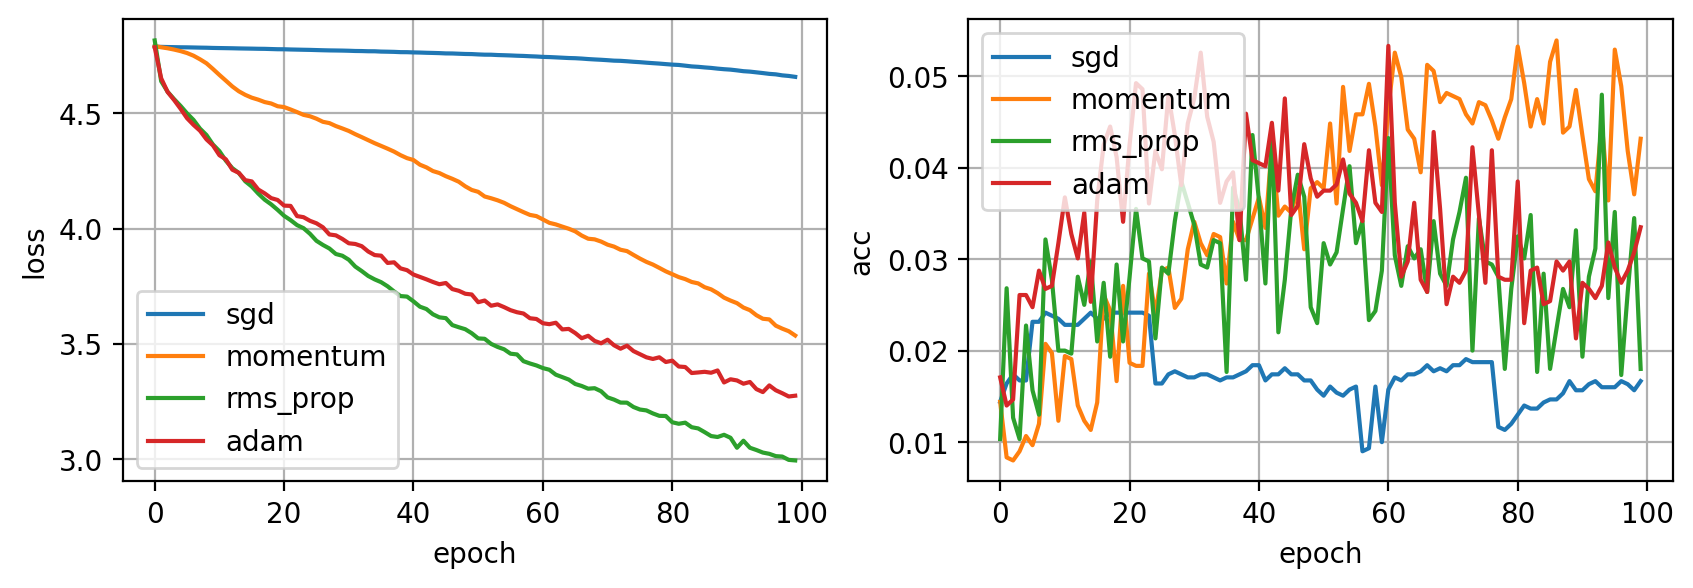

In [92]:
import matplotlib.pyplot as plt

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_sgd['loss'], label="sgd")
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_rms['loss'], label="rms_prop")
ax.plot(hist_adam['loss'], label="adam")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_sgd['val_acc'], label="sgd")
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_rms['val_acc'], label="rms_prop")
ax.plot(hist_adam['val_acc'], label="adam")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

Observamos que ADAM es mas constante

## *Learning Rate Scheduling*

In [139]:
def batch_acc_from_logits(logits, y_true):
    preds = logits.argmax(dim=1)
    return (preds == y_true).float().mean().item()

In [140]:
def fit(model, dataloader, optimizer, scheduler=None, epochs=100, log_each=10, weight_decay=0, early_stopping=0):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc, lr = [], [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        for param_group in optimizer.param_groups:
            lr.append(param_group['lr'])
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            #y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(batch_acc_from_logits(y_pred, y_b))
            #_acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                #y_probas = torch.argmax(softmax(y_pred), axis=1)
                #_acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
                _acc.append(batch_acc_from_logits(y_pred, y_b))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        if scheduler is not None:
            scheduler.step()
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f} lr {lr[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    model = build_model(D_out=len(classes))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc, 'lr': lr}

In [141]:
# mira cuántas salidas tiene tu modelo actual
print("out_features:", list(model.modules())[-1].out_features)

# mira el rango de etiquetas del primer batch
xb, yb = next(iter(dataloader['train']))
print("y_b dtype:", yb.dtype, "min:", yb.min().item(), "max:", yb.max().item())


out_features: 120
y_b dtype: torch.int64 min: 2 max: 114


In [142]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# multiplica el lr por 0.1 cada 10 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 10, 0.1)

hist_step = fit(model, dataloader, optimizer, scheduler, epochs=30)

Mejor modelo guardado con acc 0.01441 en epoch 1
Mejor modelo guardado con acc 0.02107 en epoch 3
Mejor modelo guardado con acc 0.03481 en epoch 6
Epoch 10/30 loss 4.40770 acc 0.03185 val_loss 4.50880 val_acc 0.02467 lr 0.01000
Mejor modelo guardado con acc 0.04148 en epoch 11
Mejor modelo guardado con acc 0.04989 en epoch 12
Mejor modelo guardado con acc 0.05089 en epoch 13
Mejor modelo guardado con acc 0.05189 en epoch 14
Mejor modelo guardado con acc 0.05256 en epoch 16
Epoch 20/30 loss 4.20295 acc 0.05912 val_loss 4.46468 val_acc 0.05156 lr 0.00100
Mejor modelo guardado con acc 0.05322 en epoch 21
Mejor modelo guardado con acc 0.05422 en epoch 23
Mejor modelo guardado con acc 0.05456 en epoch 25
Mejor modelo guardado con acc 0.05489 en epoch 26
Mejor modelo guardado con acc 0.05489 en epoch 30
Epoch 30/30 loss 4.16723 acc 0.06230 val_loss 4.44779 val_acc 0.05489 lr 0.00010


In [143]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# aumenta el lr por 5 epochs, luego decrece
scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.0001, max_lr=0.01, step_size_up=5, step_size_down=25)

hist_cycle = fit(model, dataloader, optimizer, scheduler, epochs=30)

Mejor modelo guardado con acc 0.01307 en epoch 1
Mejor modelo guardado con acc 0.01807 en epoch 3
Mejor modelo guardado con acc 0.02915 en epoch 4
Epoch 10/30 loss 4.49465 acc 0.03006 val_loss 4.55422 val_acc 0.02874 lr 0.00842
Mejor modelo guardado con acc 0.02941 en epoch 12
Mejor modelo guardado con acc 0.03074 en epoch 13
Mejor modelo guardado con acc 0.03474 en epoch 14
Mejor modelo guardado con acc 0.03674 en epoch 15
Mejor modelo guardado con acc 0.04281 en epoch 16
Epoch 20/30 loss 4.11887 acc 0.07763 val_loss 4.50616 val_acc 0.03741 lr 0.00446
Mejor modelo guardado con acc 0.04581 en epoch 25
Mejor modelo guardado con acc 0.04781 en epoch 26
Epoch 30/30 loss 3.84684 acc 0.12102 val_loss 4.54561 val_acc 0.03841 lr 0.00050


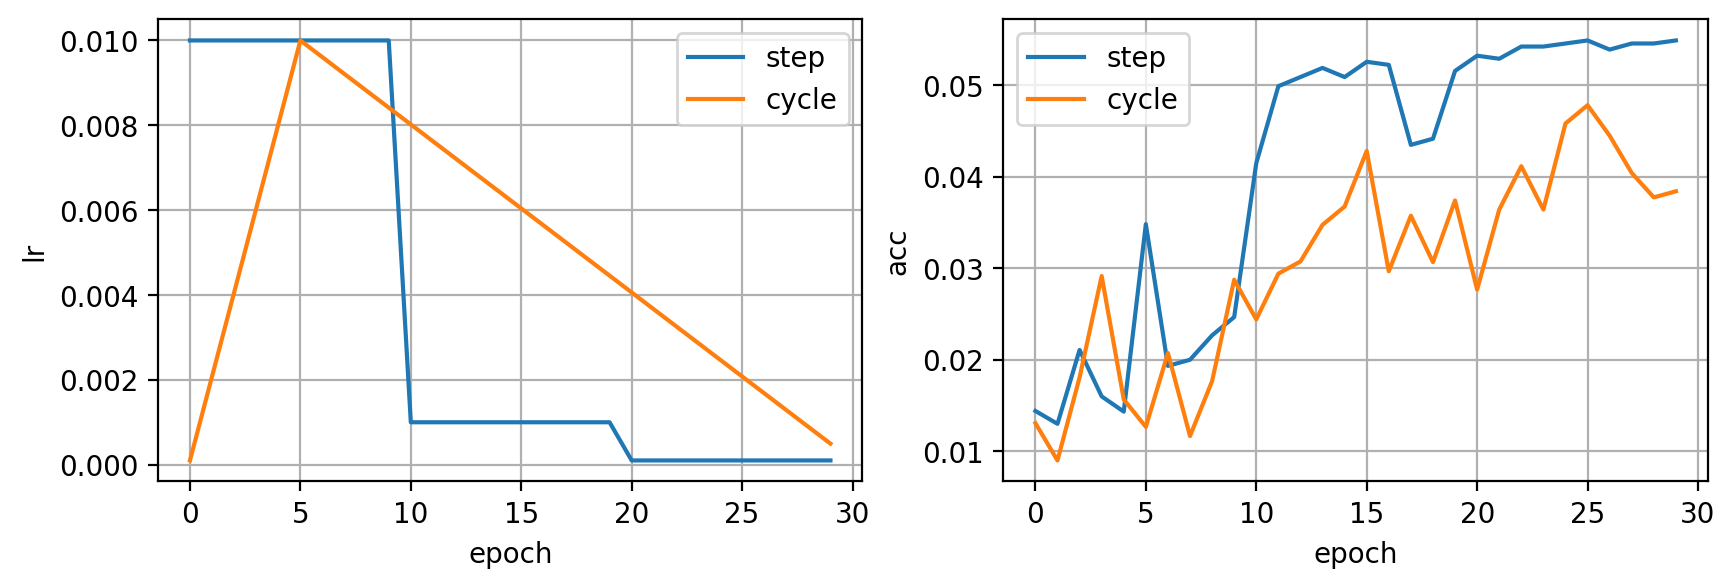

In [144]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_step['lr'], label="step")
ax.plot(hist_cycle['lr'], label="cycle")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('lr')
ax = plt.subplot(122)
ax.plot(hist_step['val_acc'], label="step")
ax.plot(hist_cycle['val_acc'], label="cycle")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

## Normalización

In [145]:
import numpy as np

mean = (train_images / 255).mean(axis=(0, 1, 2))
std = (train_images / 255).std(axis=(0, 1, 2))

mean, std

(array([0.47652312, 0.45225528, 0.39228795]),
 array([0.24633138, 0.24143949, 0.24592339]))

In [146]:
train_images_norm = ((train_images / 255) - mean) / std
train_images_norm.mean(axis=(0, 1, 2)), train_images_norm.std(axis=(0, 1, 2))

(array([-9.74256533e-12, -1.92105555e-11, -3.00434539e-11]),
 array([1., 1., 1.]))

In [ ]:
# Estadísticos desde TODO el train (o mejor, desde X_train)
mean = (train_images / 255.).mean(axis=(0, 1, 2))
std  = (train_images / 255.).std(axis=(0, 1, 2))

# Normaliza respetando tus splits ya calculados
train_images_norm = ((train_images / 255.) - mean) / std
X_train_norm = train_images_norm[np.isin(np.arange(len(train_images)), np.where(np.isin(train_images, X_train, assume_unique=False)))]

X_val_norm   = ((X_val   / 255.) - mean) / std
X_subset_norm= ((X_subset/ 255.) - mean) / std
X_test_norm  = ((X_test  / 255.) - mean) / std


In [148]:
dataset_norm = {
    'train': Dataset(X_subset_norm, y_subset),
    'val': Dataset(X_val_norm, y_val),
}

dataloader_norm = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

len(dataset_norm['train']), len(dataset_norm['val'])

(5000, 2045)

In [149]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_norm = fit(model, dataloader_norm, optimizer)

Mejor modelo guardado con acc 0.00633 en epoch 1
Mejor modelo guardado con acc 0.01541 en epoch 3
Mejor modelo guardado con acc 0.03322 en epoch 7
Mejor modelo guardado con acc 0.04396 en epoch 9
Epoch 10/100 loss 4.72806 acc 0.02010 val_loss 4.71477 val_acc 0.03456 lr 0.00100
Epoch 20/100 loss 4.54243 acc 0.02866 val_loss 4.57416 val_acc 0.02300 lr 0.00100
Epoch 30/100 loss 4.44171 acc 0.03921 val_loss 4.52684 val_acc 0.02067 lr 0.00100
Epoch 40/100 loss 4.31866 acc 0.05832 val_loss 4.49570 val_acc 0.02467 lr 0.00100
Epoch 50/100 loss 4.18535 acc 0.07106 val_loss 4.47885 val_acc 0.03241 lr 0.00100
Mejor modelo guardado con acc 0.04781 en epoch 53
Mejor modelo guardado con acc 0.04856 en epoch 55
Epoch 60/100 loss 4.07375 acc 0.08559 val_loss 4.48349 val_acc 0.04007 lr 0.00100
Mejor modelo guardado con acc 0.05896 en epoch 61
Epoch 70/100 loss 3.96616 acc 0.09873 val_loss 4.54225 val_acc 0.04548 lr 0.00100
Epoch 80/100 loss 3.85298 acc 0.11883 val_loss 4.56317 val_acc 0.03674 lr 0.0010

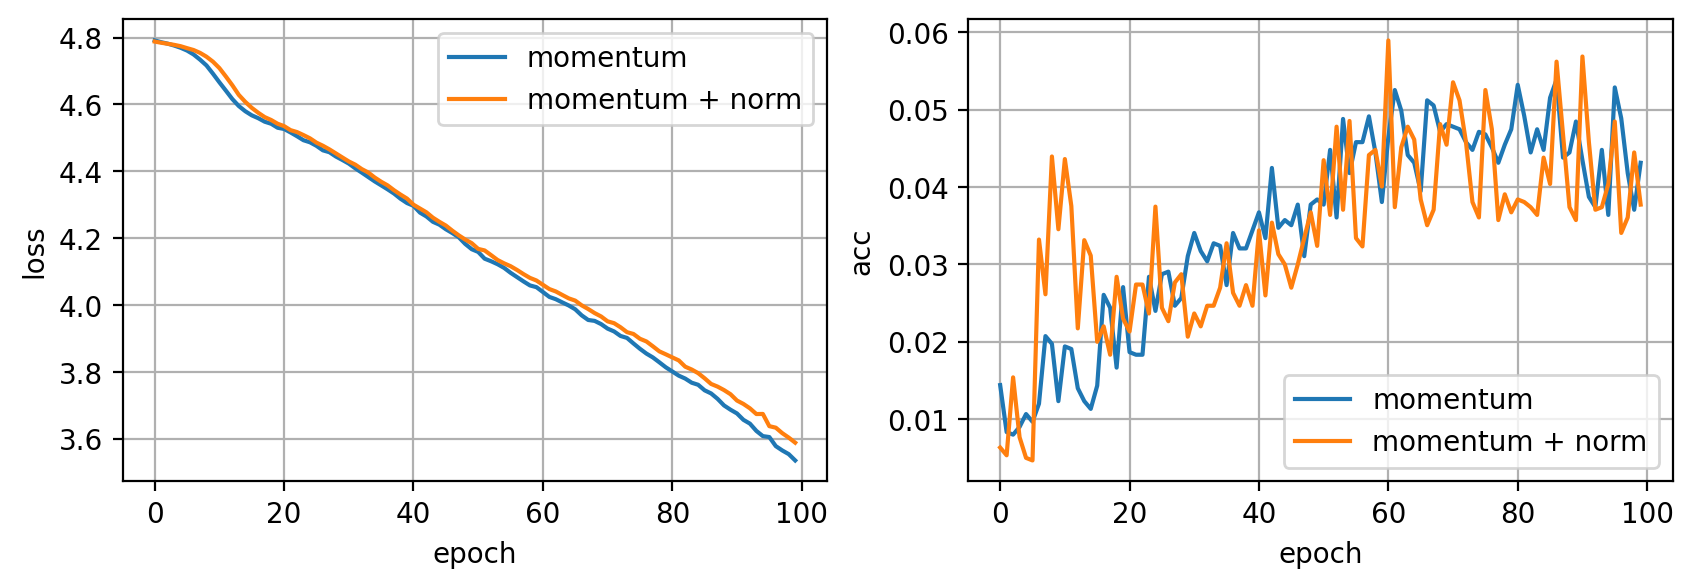

In [150]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_norm['loss'], label="momentum + norm")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_norm['val_acc'], label="momentum + norm")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

En este caso, el efecto de la normalización no es considerable (al trabajar con imágenes éste suele ser el caso).

### *Batch Normalization*

In [153]:
def build_model(D_in=32*32*3, H=100, D_out=None):
    if D_out is None:
        D_out = len(classes)
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.BatchNorm1d(H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.BatchNorm1d(H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    )

In [154]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_bn = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.01133 en epoch 1
Mejor modelo guardado con acc 0.01300 en epoch 2
Mejor modelo guardado con acc 0.03756 en epoch 3
Epoch 10/100 loss 4.02135 acc 0.18830 val_loss 4.62785 val_acc 0.02807 lr 0.00100
Epoch 20/100 loss 3.22861 acc 0.38873 val_loss 4.75392 val_acc 0.02767 lr 0.00100
Mejor modelo guardado con acc 0.04189 en epoch 28
Epoch 30/100 loss 2.31195 acc 0.59236 val_loss 5.24700 val_acc 0.02233 lr 0.00100
Epoch 40/100 loss 1.43139 acc 0.77050 val_loss 5.68101 val_acc 0.02107 lr 0.00100
Mejor modelo guardado con acc 0.04222 en epoch 41
Epoch 50/100 loss 0.86741 acc 0.87361 val_loss 6.14960 val_acc 0.03215 lr 0.00100
Epoch 60/100 loss 0.46910 acc 0.94885 val_loss 7.04077 val_acc 0.01967 lr 0.00100
Epoch 70/100 loss 0.30794 acc 0.96955 val_loss 7.34856 val_acc 0.01867 lr 0.00100
Epoch 80/100 loss 0.19622 acc 0.98467 val_loss 7.44487 val_acc 0.03015 lr 0.00100
Epoch 90/100 loss 0.10880 acc 0.99423 val_loss 7.54974 val_acc 0.02641 lr 0.00100
Epoch 100/100 l

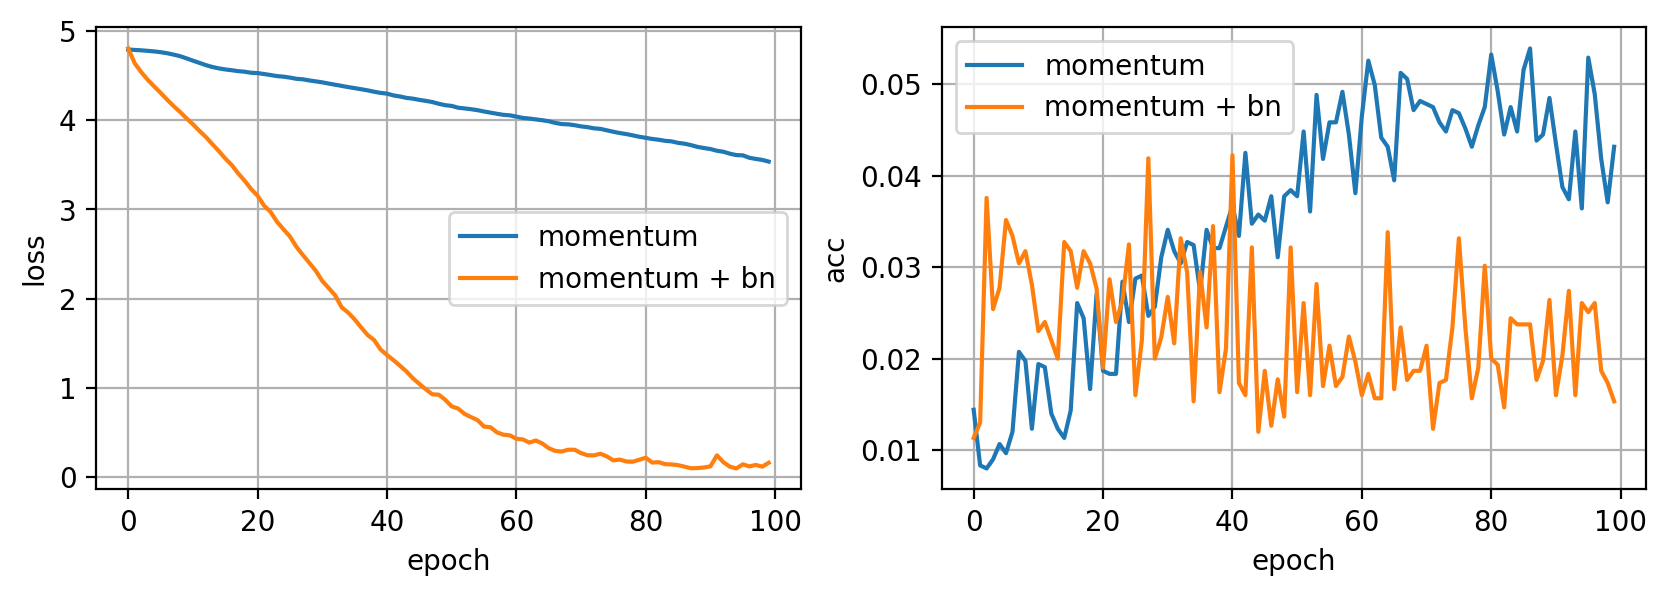

In [155]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_bn['loss'], label="momentum + bn")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_bn['val_acc'], label="momentum + bn")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

Como puedes observar, la introducción de la capa *Batch Norm* acelera muchísimo el entrenamiento, resultando en una reducción de la función de pérdida mucho más rápida (haciendo que nuestro modelo haga *overfitting* mucho más pronto). Combinando esta capa con alguna forma de [regularización](https://sensioai.com/blog/031_regularization), como por ejemplo *data augmentation* y *early stopping*, obtendremos buenos modelos capaces de generalizar de manera rápida.